# Learned Bloom Filter: Complete Pipeline

This notebook implements, benchmarks, and evaluates a complete Learned Bloom Filter pipeline using character-trigram hashing, fused inference, and a backup Bloom Filter for classifier false negatives.

The notebook reproduces the complete workflow, including model training, benchmarking, memory analysis, threshold trade-off analysis, and visualization.

## Running the Complete Pipeline

The following code executes all benchmarking, evaluation, and plotting scripts required to reproduce the experimental results.

In [1]:
import json
import subprocess
from pathlib import Path
import pandas as pd

In [ ]:
subprocess.run(
    ["python", "scripts/benchmark.py"],
    check=True
)

subprocess.run(
    ["python", "scripts/train_model.py"],
    check=True
)

subprocess.run(
    [
        "python",
        "scripts/benchmark_fused_cpp.py",
        "--impl",
        "python",
        "--num-queries",
        "50000"
    ],
    check=True
)

subprocess.run(
    [
        "python",
        "scripts/benchmark_fused_cpp.py",
        "--impl",
        "cpp",
        "--num-queries",
        "50000"
    ],
    check=True
)

subprocess.run(
    ["python", "scripts/benchmark_learned_vs_standard.py"],
    check=True
)

subprocess.run(
    ["python", "scripts/benchmark_memory_variants.py"],
    check=True
)

subprocess.run(
    ["python", "scripts/benchmark_threshold_tradeoff.py"],
    check=True
)

CompletedProcess(args=['python', 'scripts/benchmark_threshold_tradeoff.py'], returncode=0)

In [4]:
subprocess.run(["python", "scripts/plot_memory_variants.py"], check=True)
subprocess.run(["python", "scripts/plot_threshold_tradeoff.py"], check=True)

hash_summary = json.load(open("results/hash_benchmark/summary.json"))

hash_results = {
    x["name"]: x
    for x in hash_summary["results"]
}

python_summary = json.load(open("results/fused_python_benchmark/summary.json"))
cpp_summary = json.load(open("results/fused_cpp_benchmark/summary.json"))


## Pipeline Overview

This notebook reproduces the complete Learned Bloom Filter pipeline.

The implementation consists of four main phases:

### Phase 01 — Word Token Baseline
- HashingVectorizer (word unigrams)
- sklearn Logistic Regression
- Baseline latency and accuracy benchmark

### Phase 02 — Character Trigram Baseline
- Character trigram hashing
- Improved classification quality
- Baseline for fused inference

### Phase 03 — Fused Inference
- Pure Python fused scorer
- Native C++ scorer using pybind11
- Performance comparison

### Phase 04 — Learned Bloom Filter
- Logistic Regression classifier
- Backup Bloom Filter storing classifier false negatives
- Learned vs Standard Bloom Filter comparison


In [5]:
pd.DataFrame([
    {
        "Phase": "Word Tokens",
        "Latency": hash_results["step_01_word_tokens"]["mean_latency_ns"],
        "QPS": hash_results["step_01_word_tokens"]["qps"],
        "ROC-AUC": hash_results["step_01_word_tokens"]["roc_auc"],
    },
    {
        "Phase": "Char Trigrams",
        "Latency": hash_results["step_02_char_trigrams"]["mean_latency_ns"],
        "QPS": hash_results["step_02_char_trigrams"]["qps"],
        "ROC-AUC": hash_results["step_02_char_trigrams"]["roc_auc"],
    },
    {
        "Phase": "Python Fused",
        "Latency": python_summary["mean_latency_ns"],
        "QPS": python_summary["qps"],
        "ROC-AUC": python_summary["roc_auc"],
    },
    {
        "Phase": "Native C++",
        "Latency": cpp_summary["mean_latency_ns"],
        "QPS": cpp_summary["qps"],
        "ROC-AUC": cpp_summary["roc_auc"],
    },
])

,Phase,Latency,QPS,ROC-AUC
0,Word Tokens,101537.860,9.848543e+03,0.992039
1,Char Trigrams,139796.500,7.153255e+03,0.992868
2,Python Fused,144540.852,6.918459e+03,0.964446
3,Native C++,605.166,1.652439e+06,0.964444


## Observations

The benchmark results show a clear progression in inference efficiency across the four implementations.

- Character trigram hashing provides slightly better ROC-AUC than word-token hashing.
- Fusing feature extraction and inference in Python substantially reduces latency.
- The Native C++ implementation achieves the highest throughput while preserving identical model quality.
- The optimization improves inference speed without changing the learned model itself.

## Benchmark Summary

The following table summarizes the performance of all inference implementations.

Metrics reported:

- Mean latency
- Throughput
- ROC-AUC

The results demonstrate the progression from the original sklearn pipeline to the optimized Native C++ fused implementation.

## Memory Analysis

The following visualizations compare the memory consumption of different Learned Bloom Filter variants and illustrate the effect of changing the classifier threshold on memory usage.

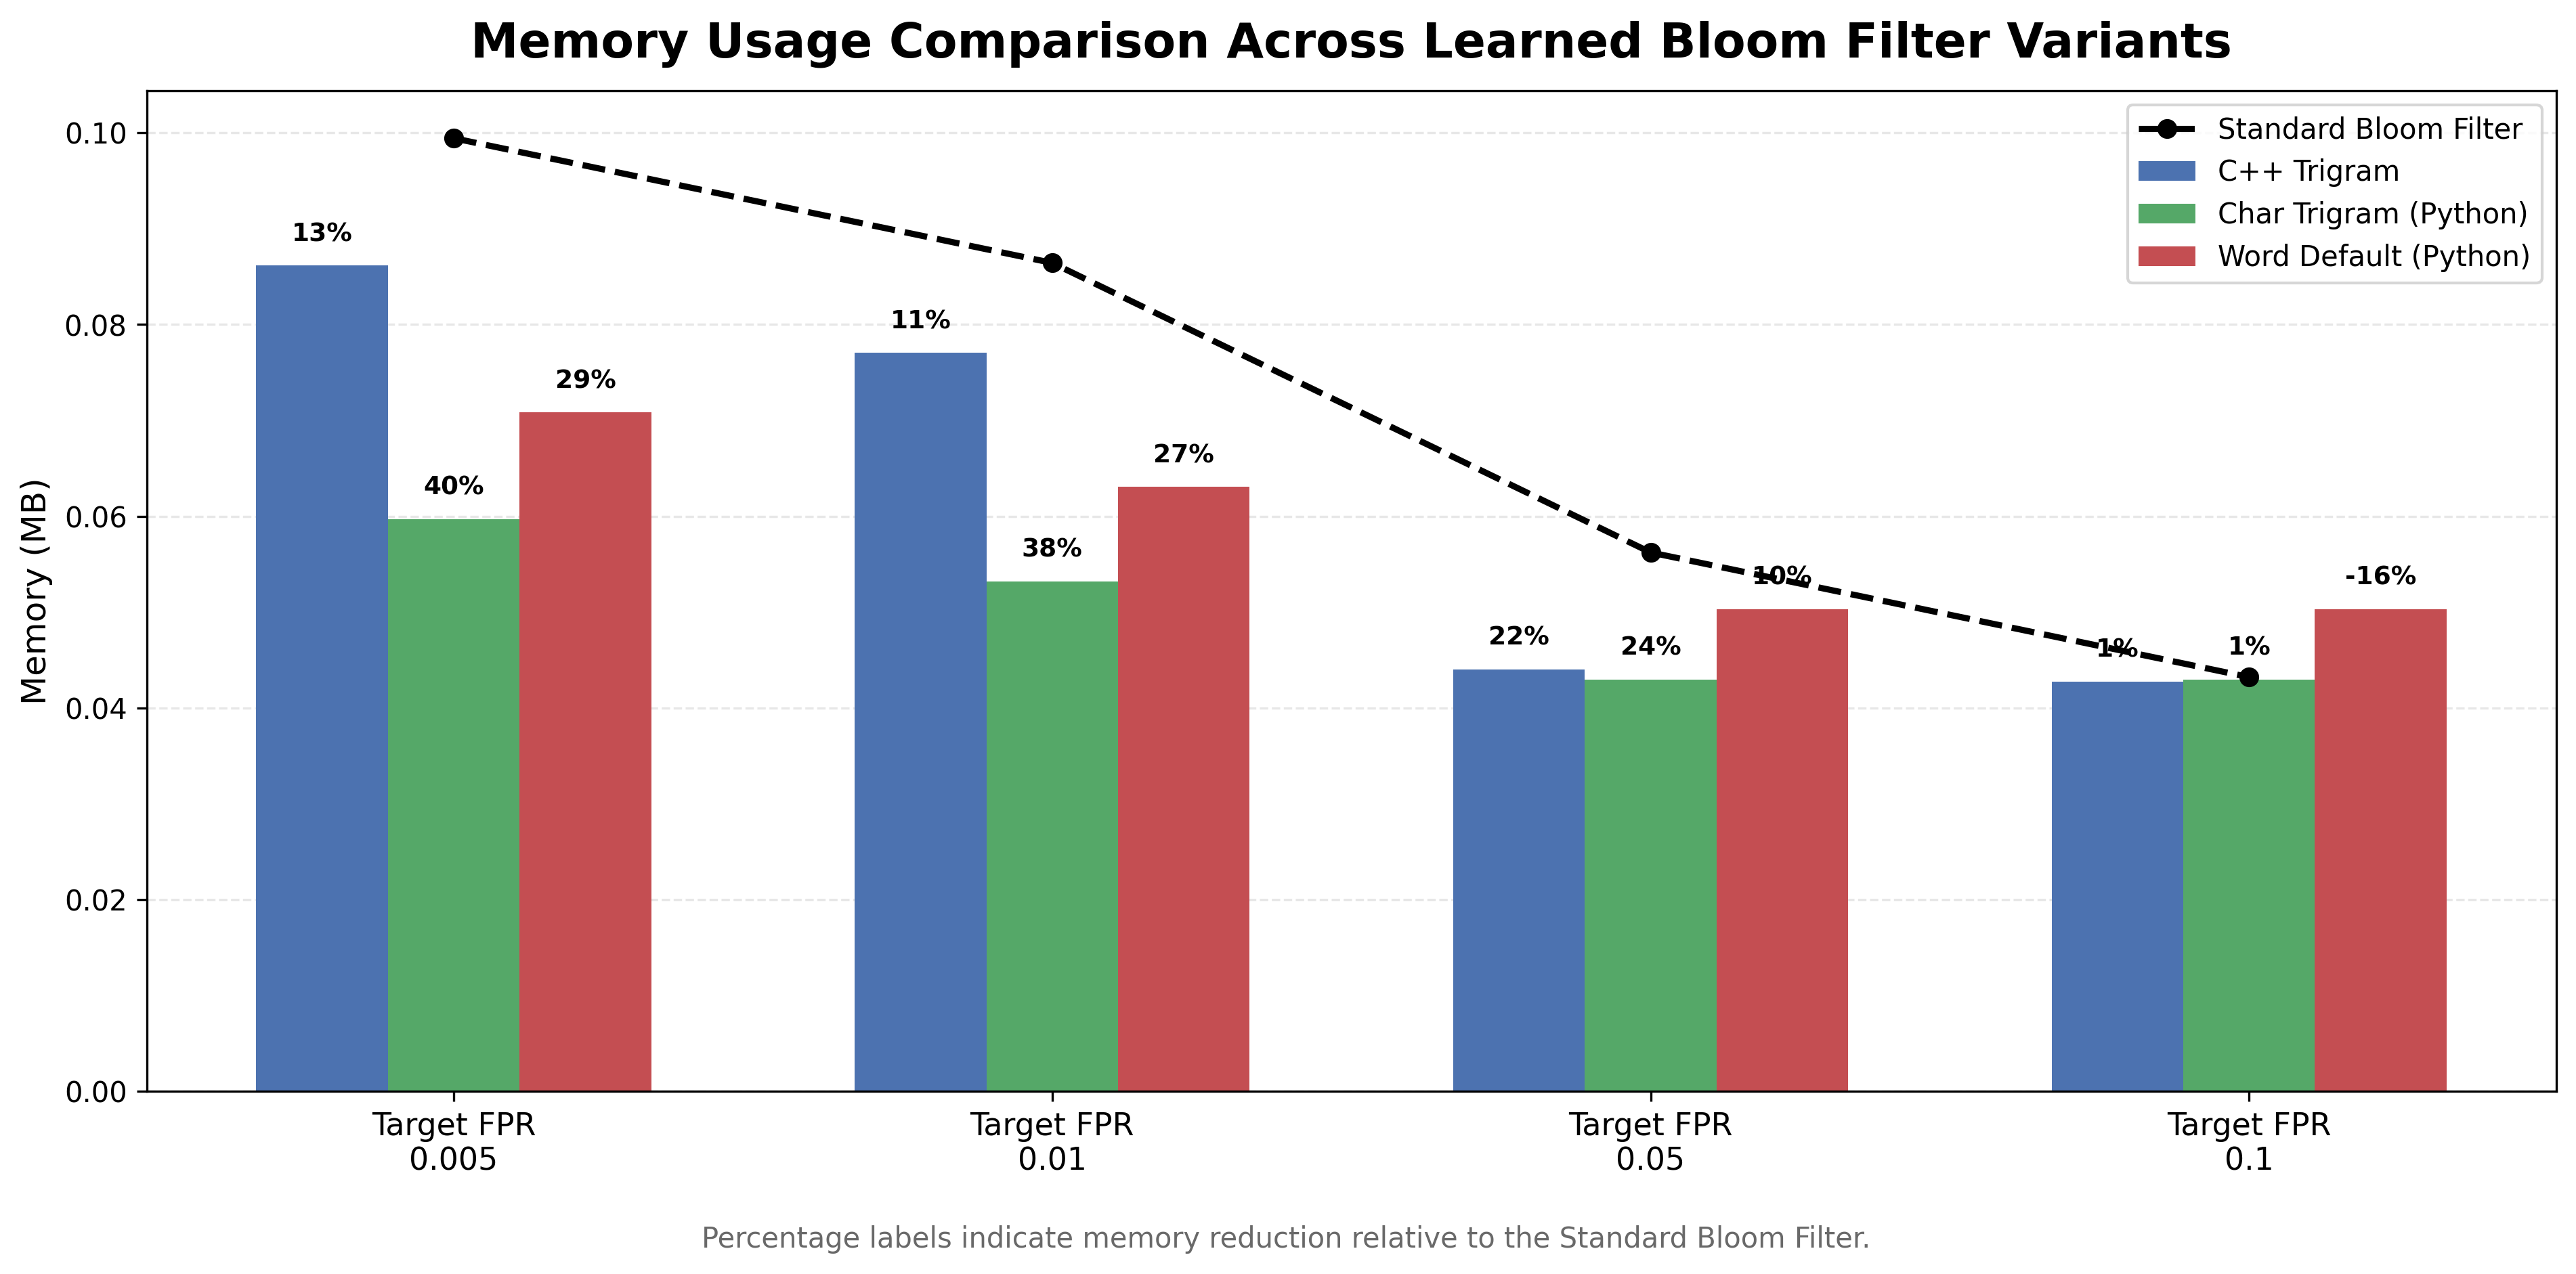

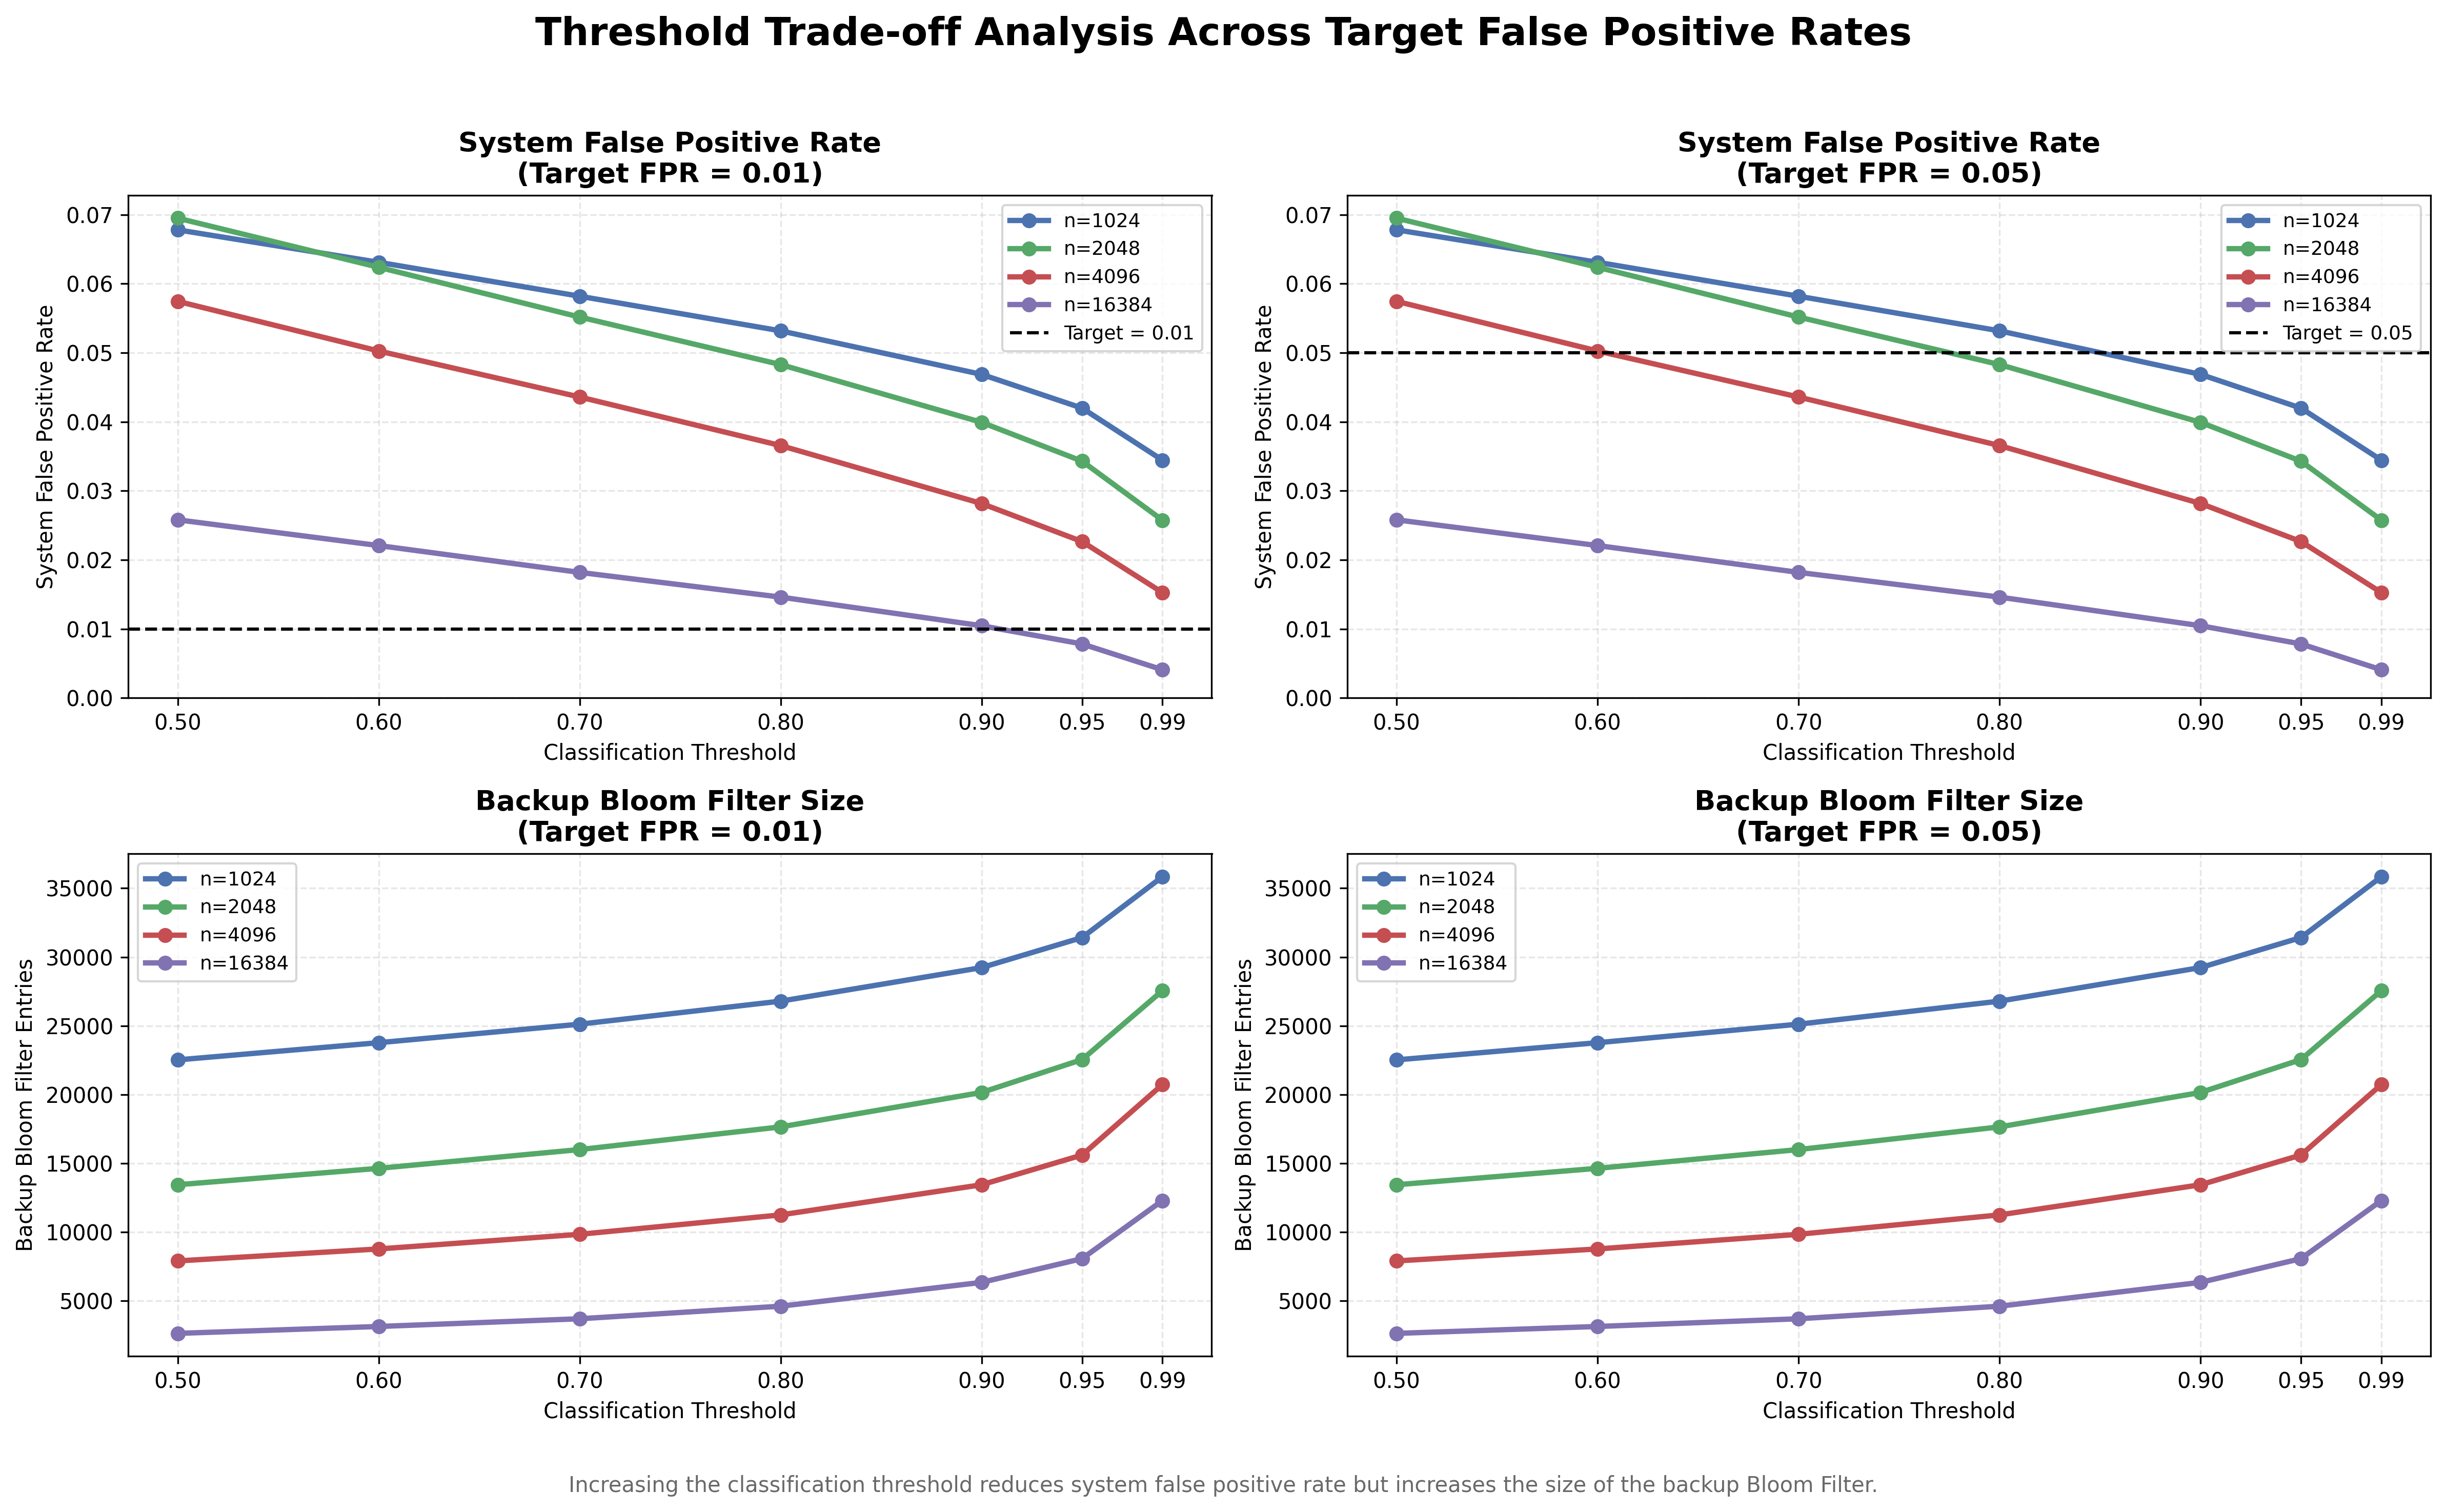

In [6]:
from IPython.display import Image, display

display(Image("results/memory_usage_variants/memory_usage_variants.png"))
display(Image("results/threshold_tradeoff/threshold_tradeoff.png")) 

# Conclusion

This notebook presented the complete implementation and evaluation of a Learned Bloom Filter using character-trigram hashing, fused inference, and a backup Bloom Filter for classifier false negatives.

The experimental results demonstrate that:

- Character-trigram hashing improves classification quality compared to the word-token baseline while maintaining competitive inference performance.
- Fusing feature extraction and inference significantly reduces query latency, with the Native C++ implementation achieving the highest throughput while preserving the same predictive performance as the Python implementation.
- The final Learned Bloom Filter reduces memory usage by approximately **50.5%** compared to a Standard Bloom Filter by storing only classifier false negatives in the backup Bloom Filter.
- The memory analysis shows that different model representations provide different memory savings, while the threshold trade-off analysis illustrates that increasing the classification threshold reduces the system false positive rate but increases the size of the backup Bloom Filter.

Overall, the project demonstrates that combining machine learning with probabilistic data structures provides an effective trade-off between memory efficiency, query performance, and false positive rate, making Learned Bloom Filters a practical alternative to traditional Bloom Filters for large-scale membership testing applications.